In [1]:
#Packages
import os
from dotenv import load_dotenv
from openai import OpenAI
import json
import time
import numpy as np
import pandas as pd
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Data Load
df_granular = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\GPT_Granular_Processed.csv")

#Importing OpenAI API
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_KEY")

#Output Path
LOCAL_PAYLOAD_FILE = "transcripts_batch_input.jsonl"

#Pydantic Validation: Hard structures for the continuous sentiment scores
class FinancialSentiment(BaseModel):
    positive: float = Field(description="Probability score for positive sentiment, between 0.0 and 1.0")
    negative: float = Field(description="Probability score for negative sentiment, between 0.0 and 1.0")
    neutral: float = Field(description="Probability score for neutral sentiment, between 0.0 and 1.0")

In [3]:
#Payload Function
def generate_transcript_batch_file(df, text_col='gpt_input', output_path=LOCAL_PAYLOAD_FILE):

    system_prompt = (
        """You are an expert financial NLP system. Analyze the provided standalone corporate transcript segment
        representing an isolated analyst turn or executive statement and determine the exact probability distribution
        for Positive, Negative, and Neutral sentiment based on corporate realities and macro context. Evaluate the text
        as an independent unit."""
    )
    
    #Extracts the base dictionary layout from Pydantic
    base_schema = FinancialSentiment.model_json_schema()
    base_schema["type"] = "object"
    base_schema["additionalProperties"] = False
    
    with open(output_path, 'w', encoding='utf-8') as f:
        for idx, row in df.iterrows():
            raw_text = str(row[text_col]).strip()
            if not raw_text:
                continue
                
            batch_request = {
                "custom_id": str(idx),
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": "gpt-4o-mini",
                    "temperature": 0.0,
                    "max_completion_tokens": 100,
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": raw_text}
                    ],
                    "response_format": {
                        "type": "json_schema",
                        "json_schema": {
                            "name": "transcript_sentiment_schema",
                            "strict": True,
                            "schema": base_schema # Uses the explicitly locked dictionary
                        }
                    }
                }
            }
            f.write(json.dumps(batch_request) + '\n')
            
    print(f"Success: Generated local payload file containing {len(df)} requests.")

#Execution:
generate_transcript_batch_file(df_granular)

Success: Generated local payload file containing 13341 requests.


In [4]:
#Uploading the Payload file to Server Queue
def dispatch_transcript_batch(input_path=LOCAL_PAYLOAD_FILE):
    client = OpenAI()
    
    uploaded_file = client.files.create(
        file=open(input_path, "rb"),
        purpose="batch"
    )
    
    print(f"File fully uploaded to cloud bucket. Remote File ID: {uploaded_file.id}")
    
    batch_job = client.batches.create(
        input_file_id=uploaded_file.id,
        endpoint="/v1/chat/completions",
        completion_window="24h",
        metadata={"description": "MSc Transcripts Run - 13341 Rows"}
    )
    
    print(f"Success: Batch successfully triggered!")
    print(f"BATCH ID: {batch_job.id}")
    return batch_job.id

#Execution:
current_batch_id = dispatch_transcript_batch()

File fully uploaded to cloud bucket. Remote File ID: file-U8NfRxKXPwZNpRAT9NoPwz
Success: Batch successfully triggered!
BATCH ID: batch_6a491a4e47c081909520d7d28cdec42b


In [5]:
#Automated Progress tracker Loop
def wait_for_batch_completion(batch_id, check_interval_seconds=60):
    
    client = OpenAI()

    while True:
        job = client.batches.retrieve(batch_id)
        status = job.status
        
        if status == "completed":
            print(f"\nSuccess:Asynchronous cloud processing finished.")
            return job.output_file_id
            
        elif status in ["failed", "cancelled", "expired"]:
            print(f"\nPipeline Failure: Execution ended with terminal status: {status}")
            if hasattr(job, 'errors') and job.errors:
                print(f"Error Log: {job.errors}")
            return None
            
        else:
            # Active processing states: queued, validating, in_progress, or finalizing
            completed_rows = job.request_counts.completed if job.request_counts else 0
            total_rows = job.request_counts.total if job.request_counts else 13341
            
            print(f"Cloud Status: '{status}' | Progress Tracker: {completed_rows}/{total_rows} entries processed.", end="\r")
            time.sleep(check_interval_seconds)

In [6]:
#Execution
start_time = time.time()
cloud_output_file_id = wait_for_batch_completion(current_batch_id)
print(f"\nInference loop successfully concluded in {time.time() - start_time:.2f} seconds.")

Cloud Status: 'finalizing' | Progress Tracker: 13341/13341 entries processed..
Success:Asynchronous cloud processing finished.

Inference loop successfully concluded in 2124.75 seconds.


In [7]:
#Merging Results
def download_and_compile_features(output_file_id, original_df):
    """
    Downloads remote cloud vectors, processes raw float fields, maps hard labels 
    via argmax channels, and returns an index-aligned merged master matrix.
    """
    client = OpenAI()
    file_response = client.files.content(output_file_id)
    
    parsed_records = []
    
    for line in file_response.text.strip().split('\n'):
        if not line:
            continue
        row_data = json.loads(line)
        custom_id = int(row_data["custom_id"])
        
        #Accessing structured Pydantic body variables
        raw_content = row_data["response"]["body"]["choices"][0]["message"]["content"]
        scores = json.loads(raw_content)
        
        p_pos = float(scores["positive"])
        p_neg = float(scores["negative"])
        p_neu = float(scores["neutral"])
        
        #Calculating net sentiment
        net_sentiment = p_pos - p_neg
        
        #Generating hard discrete categorical label mapping
        channels = [p_neg, p_neu, p_pos]
        max_idx = np.argmax(channels)
        
        if max_idx == 0:
            hard_label = -1  #Negative probability
        elif max_idx == 1:
            hard_label = 0   #Neutral probability
        else:
            hard_label = 1   #Positive probability
            
        parsed_records.append({
            "df_index": custom_id,
            "gpt_pos": p_pos,
            "gpt_neg": p_neg,
            "gpt_neu": p_neu,
            "gpt_net_sentiment": net_sentiment,
            "gpt_hard_label": hard_label
        })
        
    #Building final dataframe
    gpt_features_df = pd.DataFrame(parsed_records)
    gpt_features_df.set_index("df_index", inplace=True)
    final_merged_df = original_df.join(gpt_features_df, how="left")
    print("Success: Extraction pipeline completed!")
    return final_merged_df

#Execution:
transcript_final_df = download_and_compile_features(cloud_output_file_id, df_granular)

Success: Extraction pipeline completed!


In [8]:
#Updated Dataframe with GPT sentiment scores
transcript_final_df.head(2)

,index,ticker,fiscal_year,fiscal_quarter,calendar_date,company_name,sector,section_type,speaker,role,...,text,turn_word_count,transcript_total_words,gpt_input,gpt_input_len,gpt_pos,gpt_neg,gpt_neu,gpt_net_sentiment,gpt_hard_label
0,1,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Abhey Lamba,executive,...,"Thanks, operator, and good afternoon. Thank yo...",233,10399,TITLE: ADSK Call - Abhey Lamba (executive) | S...,242,0.20,0.1,0.70,0.10,0
1,2,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Andrew Anagnost,executive,...,"Thanks, Abhey. We started off fiscal '20 with ...",213,10399,TITLE: ADSK Call - Andrew Anagnost (executive)...,222,0.75,0.1,0.15,0.65,1


### Visuals

In [9]:
#Core Styling Configurations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 14,
    'figure.titlesize': 16
})

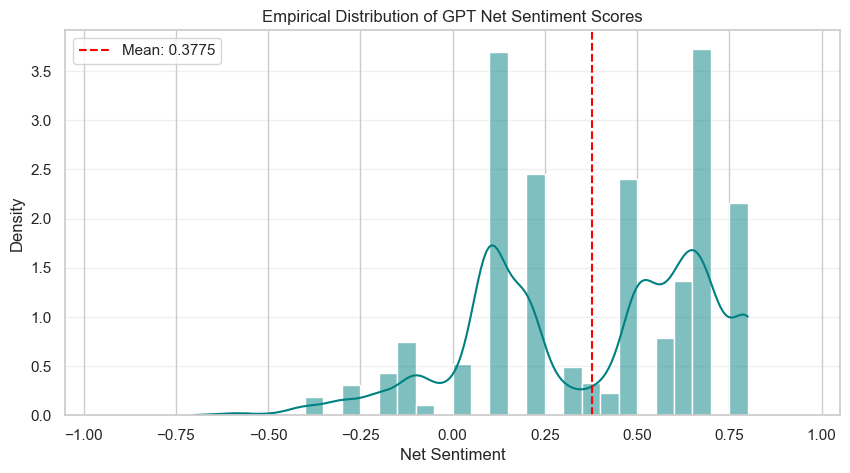

In [21]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(transcript_final_df['gpt_net_sentiment'], bins=30, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(transcript_final_df['gpt_net_sentiment'].mean(), color='red', linestyle='--', 
            label=f"Mean: {transcript_final_df['gpt_net_sentiment'].mean():.4f}")

plt.title('Empirical Distribution of GPT Net Sentiment Scores', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution GPT ECT.png', dpi=300)
plt.show()

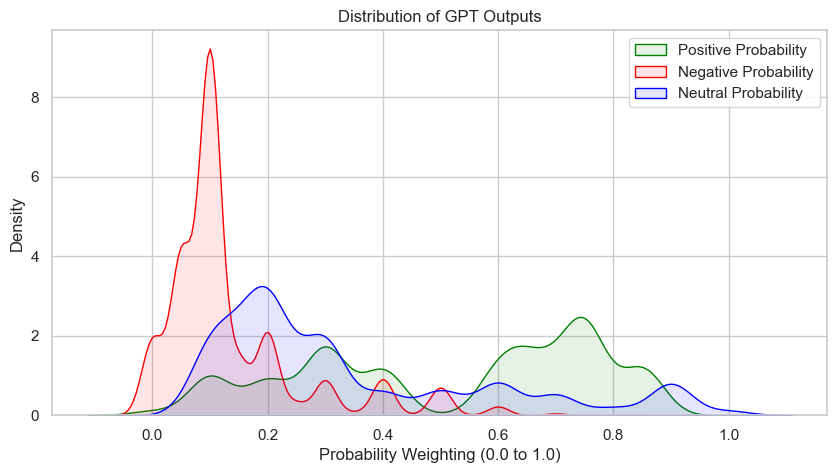

In [11]:
#Tri-Axial Distribution (Density Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(transcript_final_df['gpt_pos'], label='Positive Probability', color='green', fill=True, alpha=0.1)
sns.kdeplot(transcript_final_df['gpt_neg'], label='Negative Probability', color='red', fill=True, alpha=0.1)
sns.kdeplot(transcript_final_df['gpt_neu'], label='Neutral Probability', color='blue', fill=True, alpha=0.1)
plt.title('Distribution of GPT Outputs', fontsize=12)
plt.xlabel('Probability Weighting (0.0 to 1.0)')
plt.ylabel('Density')
plt.legend()
plt.savefig('Distribution of GPT Outputs-ECT.png', dpi=300)
plt.show()

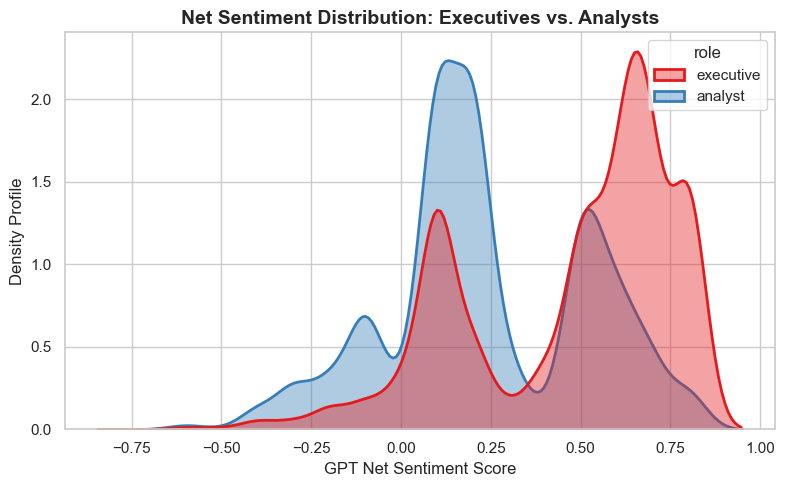

In [12]:
#Data
df = transcript_final_df[transcript_final_df['role'].str.lower().isin(['executive', 'analyst'])]
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df, 
    x='gpt_net_sentiment', 
    hue='role', 
    fill=True, 
    common_norm=False, 
    palette='Set1', 
    alpha=0.4, 
    linewidth=2
)
plt.title('Net Sentiment Distribution: Executives vs. Analysts', fontweight='bold')
plt.xlabel('GPT Net Sentiment Score')
plt.ylabel('Density Profile')
plt.tight_layout()
plt.savefig('GPT Net Sentiment Distribution-Roles.png', dpi=300)
plt.show()

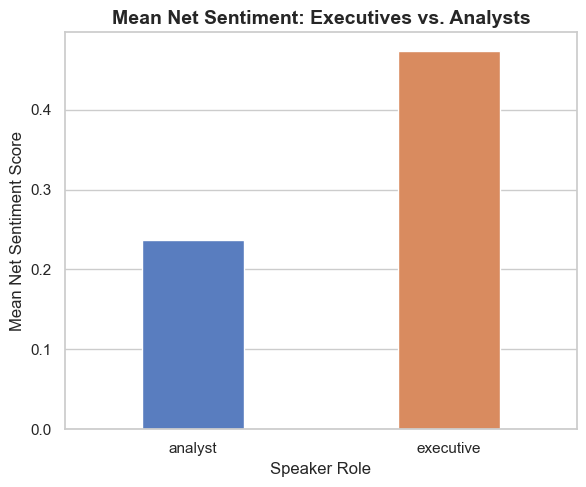

In [13]:
#Aggregate mean values for your two role types
role_summary = df.groupby('role')['gpt_net_sentiment'].mean().reset_index()
plt.figure(figsize=(6, 5))
sns.barplot(
    data=role_summary, 
    x='role', 
    y='gpt_net_sentiment', 
    hue='role',
    legend=False,
    palette='muted',
    width=0.4
)
plt.title('Mean Net Sentiment: Executives vs. Analysts', fontweight='bold')
plt.xlabel('Speaker Role')
plt.ylabel('Mean Net Sentiment Score')
plt.tight_layout()
plt.savefig('GPT Mean Sentiments-Roles.png', dpi=300)
plt.show()

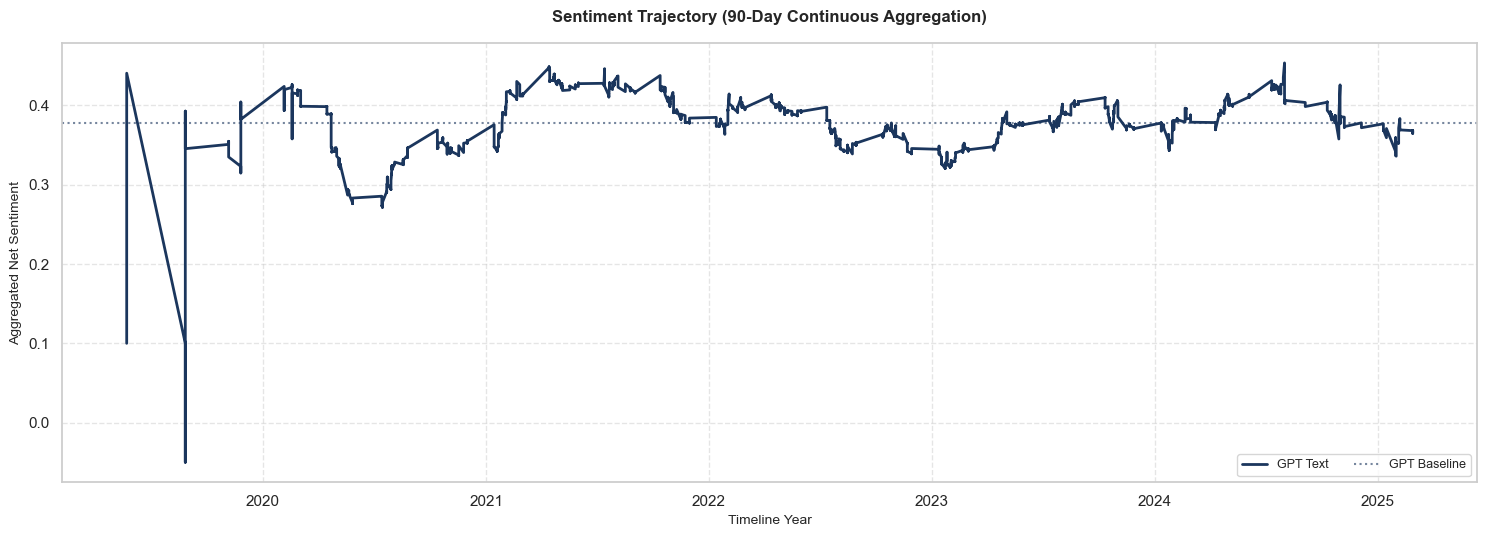

In [14]:
#Trajectory
time_df = transcript_final_df[['calendar_date', 'gpt_net_sentiment']].copy()
time_df['calendar_date'] = pd.to_datetime(time_df['calendar_date'])

#Sorting chronologically
time_df.sort_values('calendar_date', inplace=True)
time_df.set_index('calendar_date', inplace=True)

#Applying a 90-Day Continuous Rolling Mean min_periods=1 guards against empty weekend slots
rolling_sentiment = time_df.rolling(window='90D', min_periods=1).mean()

plt.rcParams['figure.figsize'] = (15, 5.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(rolling_sentiment.index, rolling_sentiment['gpt_net_sentiment'], label='GPT Text', color='#1b365d', linewidth=2)
#Establishing the historical baselines (Means across the entire multi-year corpus)
plt.axhline(y=time_df['gpt_net_sentiment'].mean(), color='#1b365d', linestyle=':', alpha=0.6, label='GPT Baseline')

#Formatting
plt.title('Sentiment Trajectory (90-Day Continuous Aggregation)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline Year', fontsize=10)
plt.ylabel('Aggregated Net Sentiment', fontsize=10)
plt.legend(loc='lower right', frameon=True, ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('GPT ECT_sentiment_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
#Saving Data with Sentiment Scores
output_path1 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\GPT_Sentiment_Score.csv'
transcript_final_df.to_csv(output_path1, index=False)
print('Success!')

Success!


In [16]:
#Range Validation
print("Net Sentiment Metric Summary Statistics")
display(transcript_final_df['gpt_net_sentiment'].describe().loc[['min', 'mean', 'max']])

Net Sentiment Metric Summary Statistics


min    -0.700000
mean    0.377539
max     0.800000
Name: gpt_net_sentiment, dtype: float64

In [18]:
#Checking Data types and verifying no missing values 
sentiment_cols = ['gpt_pos','gpt_neg','gpt_neu','gpt_net_sentiment']
print(transcript_final_df[sentiment_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 13341 entries, 0 to 13340
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gpt_pos            13341 non-null  float64
 1   gpt_neg            13341 non-null  float64
 2   gpt_neu            13341 non-null  float64
 3   gpt_net_sentiment  13341 non-null  float64
dtypes: float64(4)
memory usage: 417.0 KB
None


In [19]:
#The Zero-Sentiment Neutrality Check
#Calculate the percentage of rows where positive and negative are perfectly balanced (usually 0.0)
neutral_inertia_rate = (transcript_final_df['gpt_net_sentiment'] == 0.0).mean() * 100
print(f"Neutral Rate: {neutral_inertia_rate:.2f}% of the corpus is perfectly neutral.")

Neutral Rate: 2.59% of the corpus is perfectly neutral.


This low neutrality rate means the prediction models will have a much richer, highly differentiated set of signals to train on.